In [1066]:
import pandas as pd

train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

# EDA

In [1067]:
# To answer questions in assignment4 pdf
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42234 non-null  int64  
 1   name                            42234 non-null  str    
 2   host_id                         42234 non-null  int64  
 3   host_name                       42216 non-null  str    
 4   host_total_listings_count       42218 non-null  float64
 5   host_has_profile_pic            42218 non-null  str    
 6   host_identity_verified          42218 non-null  str    
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   42234 non-null  str    
 9   latitude                        42234 non-null  float64
 10  longitude                       42234 non-null  float64
 11  room_type                       42234 non-null  str    
 12  minimum_nights                  42234 non-n

In [1068]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              8199 non-null   int64  
 1   name                            8199 non-null   str    
 2   host_id                         8199 non-null   int64  
 3   host_name                       8199 non-null   str    
 4   host_total_listings_count       8199 non-null   float64
 5   host_has_profile_pic            8199 non-null   str    
 6   host_identity_verified          8199 non-null   str    
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   8199 non-null   str    
 9   latitude                        8199 non-null   float64
 10  longitude                       8199 non-null   float64
 11  room_type                       8199 non-null   str    
 12  minimum_nights                  8199 non-null

In [1069]:
train_df['price'].describe()

count    42234.000000
mean       166.242743
std         98.380093
min         50.000000
25%         90.000000
50%        141.000000
75%        215.000000
max        500.000000
Name: price, dtype: float64

In [1070]:
#answer to question 2
train_df['price'].median()

np.float64(141.0)

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'host_total_listings_count'}>,
        <Axes: title={'center': 'neighbourhood_group'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'number_of_reviews_ltm'}>],
       [<Axes: title={'center': 'accommodates'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'beds'}>,
        <Axes: title={'center': 'availability_30'}>],
       [<Axes: title={'center': 'availability_60'}>,
        <Axes: title={'center': 'availability_90'}>,
        <Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axe

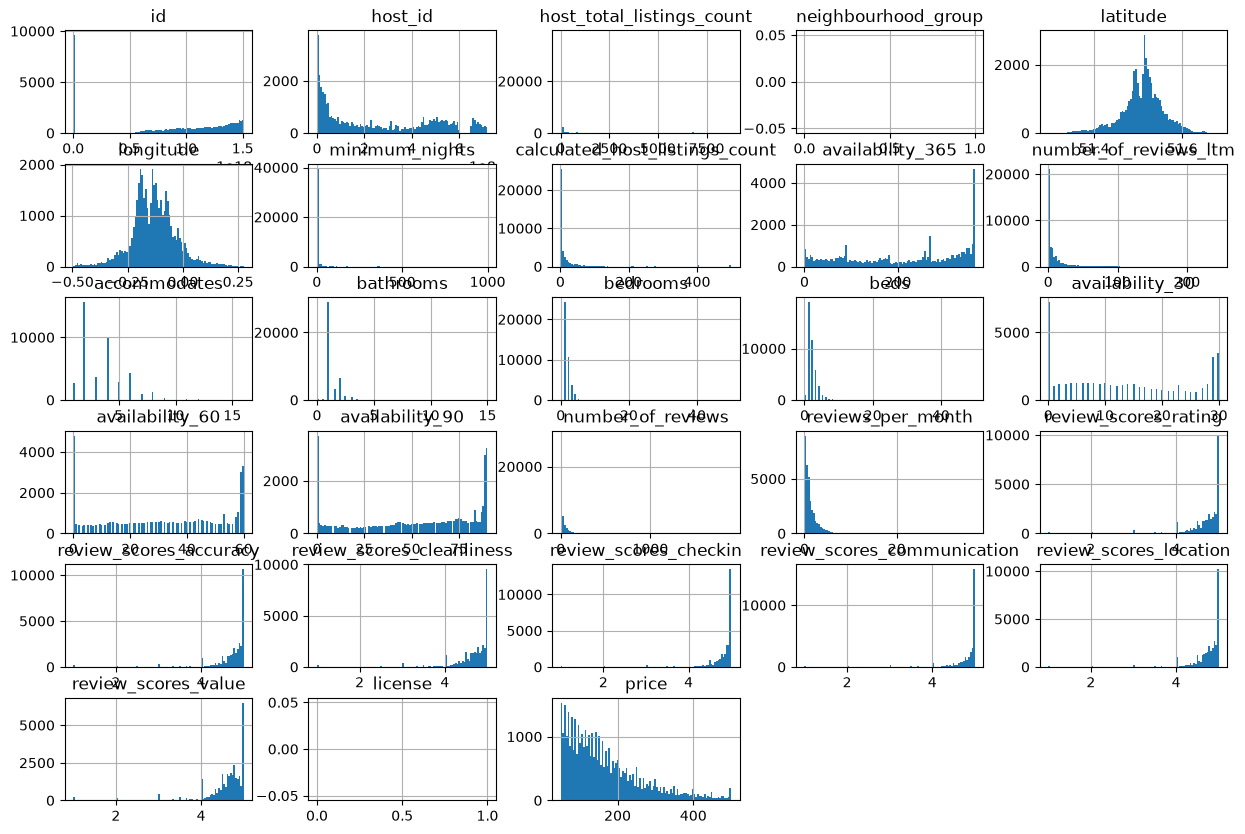

In [1071]:
train_df.hist(bins=100, figsize=(15,10))

In [1072]:
# unique values and their counts
for col in train_df.columns:
    print('--------')
    print(train_df[col].value_counts(dropna=False))

--------
id
863718884129314541     1
1246272787951735423    1
995836785136017274     1
888497692875319566     1
1069328087003020991    1
                      ..
52667545               1
1424101240983641464    1
1328874387841665633    1
2576995                1
750547105050926406     1
Name: count, Length: 42234, dtype: int64
--------
name
Flat in London                                       14
Standard Single Room                                 12
Letzi Ensuite Room | 10 Mins Wembley | Fast WiFi     11
Seven Dials Hotel, Covent Garden, Single en suite    11
Private Double Room in Warren Street                 11
                                                     ..
Lovely bedroom in a large flat                        1
River view 2 bedroom flat                             1
Charming West London Mews House                       1
Dbl Room, W'stow Central 2 mins                       1
Double room @ Hackney, near Victoria Park London      1
Name: count, Length: 41118, dtype: int64
-

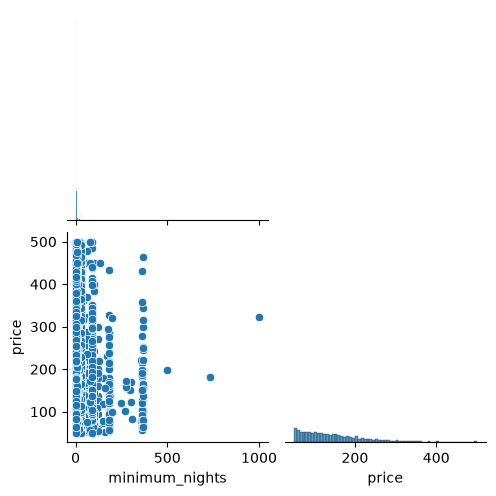

In [1073]:
# is there a correlation between minimum nights and price
import seaborn as sns
sns.pairplot(train_df[['minimum_nights', 'price']], corner=True)

<Axes: xlabel='minimum_nights', ylabel='price'>

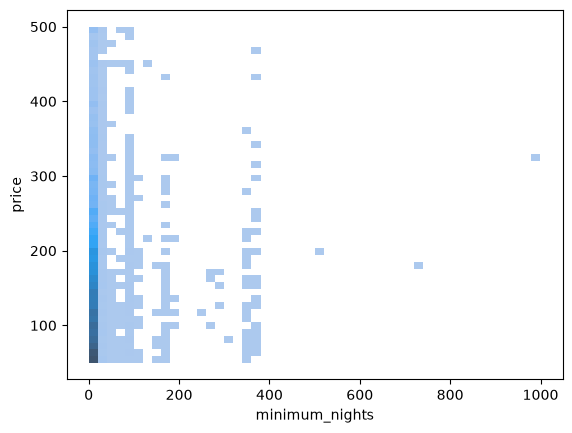

In [1074]:
sns.histplot(bins=50, x=train_df['minimum_nights'], y=train_df['price'])

In [1075]:
train_df['price'].corr(train_df['minimum_nights'])

np.float64(0.032336063826619195)

In [1076]:
train_df.corr(numeric_only=True)['price'].sort_values()

number_of_reviews                -0.107712
reviews_per_month                -0.102201
number_of_reviews_ltm            -0.100551
longitude                        -0.057776
review_scores_communication      -0.009543
host_id                          -0.007391
review_scores_value              -0.004885
latitude                         -0.003684
review_scores_checkin            -0.002452
review_scores_accuracy            0.021345
id                                0.023595
availability_90                   0.029260
minimum_nights                    0.032336
review_scores_rating              0.037623
availability_60                   0.046517
review_scores_cleanliness         0.048742
availability_30                   0.050317
availability_365                  0.073709
review_scores_location            0.108153
host_total_listings_count         0.117902
calculated_host_listings_count    0.204432
bathrooms                         0.368218
beds                              0.411513
bedrooms   

# Data Cleansing/ Feature Engineering

In [ ]:
#removing totally null columns and string columns except for neighborhood
train_df.drop(['id', 'name', 'host_name', 'host_id', 'host_has_profile_pic', 'neighbourhood_group', 'amenities', 'last_review', 'review_scores_communication', 'review_scores_value', 'review_scores_checkin', 'license'], axis=1, inplace=True)
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_total_listings_count       42218 non-null  float64
 1   host_identity_verified          42218 non-null  str    
 2   neighbourhood                   42234 non-null  str    
 3   room_type                       42234 non-null  str    
 4   calculated_host_listings_count  42234 non-null  int64  
 5   availability_365                42234 non-null  int64  
 6   number_of_reviews_ltm           42234 non-null  int64  
 7   accommodates                    42234 non-null  int64  
 8   bathrooms                       42192 non-null  float64
 9   bedrooms                        42187 non-null  float64
 10  beds                            42154 non-null  float64
 11  availability_30                 42234 non-null  int64  
 12  availability_60                 42234 non-n

array([[<Axes: title={'center': 'host_total_listings_count'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'number_of_reviews_ltm'}>],
       [<Axes: title={'center': 'accommodates'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'beds'}>],
       [<Axes: title={'center': 'availability_30'}>,
        <Axes: title={'center': 'availability_60'}>,
        <Axes: title={'center': 'availability_90'}>,
        <Axes: title={'center': 'number_of_reviews'}>],
       [<Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'review_scores_rating'}>,
        <Axes: title={'center': 'review_scores_accuracy'}>,
        <Axes: title={'center': 'review_scores_cleanliness'}>],
       [<Axes: title={'center': 'review_scores_location'}>,
        <Axes: title={'center': 'price'}>, <Axes: >, <Axe

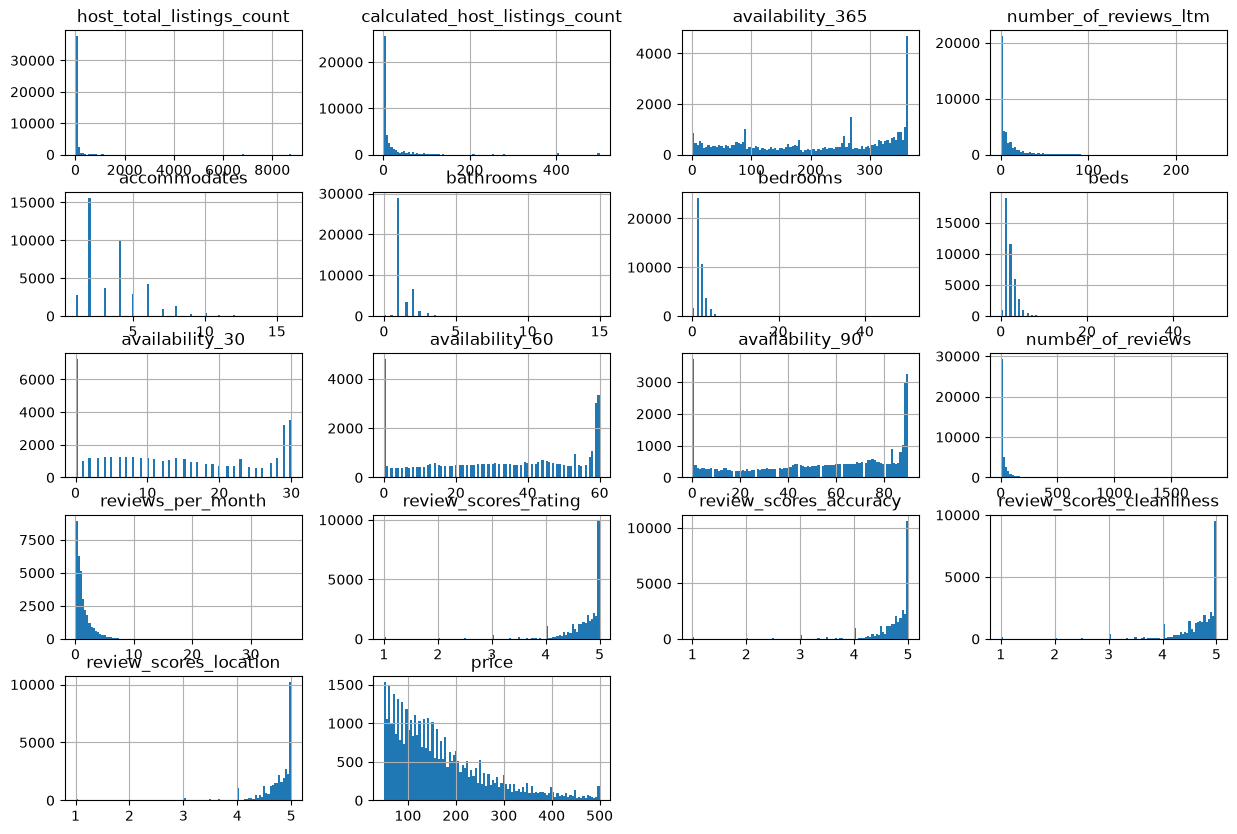

In [1078]:
cols = [c for c in train_df.columns if not c.startswith('neighbourhood_')]
cols = [c for c in cols if not c.startswith('room_type_')]
cols = [c for c in cols if not c.startswith('host_identity_verified_')]
train_df[cols].hist(bins=100, figsize=(15,10))

In [1079]:
#neighborhood has no Nan values
for col in train_df.select_dtypes(include="number").columns:
    train_df[col] = train_df[col].fillna(train_df[col].median())

In [1080]:
#one-hot encoding neighborhood
#Parts taken from Ryan and Matt Datascience YT tutorial on sklearn onehot encoder
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')


In [1081]:
ohetransform = ohe.fit_transform(train_df[['neighbourhood']])
train_df = pd.concat([train_df,ohetransform], axis=1).drop(columns='neighbourhood')

In [1082]:
ohetransform = ohe.fit_transform(train_df[['host_identity_verified']])
ohetransform.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   host_identity_verified_f    42234 non-null  float64
 1   host_identity_verified_t    42234 non-null  float64
 2   host_identity_verified_nan  42234 non-null  float64
dtypes: float64(3)
memory usage: 990.0 KB


In [1083]:
train_df = pd.concat([train_df,ohetransform], axis=1).drop(columns='host_identity_verified')

In [1084]:
ohetransform = ohe.fit_transform(train_df[['room_type']])
train_df = pd.concat([train_df,ohetransform], axis=1).drop(columns='room_type')

In [1085]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 58 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   host_total_listings_count             42234 non-null  float64
 1   calculated_host_listings_count        42234 non-null  int64  
 2   availability_365                      42234 non-null  int64  
 3   number_of_reviews_ltm                 42234 non-null  int64  
 4   accommodates                          42234 non-null  int64  
 5   bathrooms                             42234 non-null  float64
 6   bedrooms                              42234 non-null  float64
 7   beds                                  42234 non-null  float64
 8   availability_30                       42234 non-null  int64  
 9   availability_60                       42234 non-null  int64  
 10  availability_90                       42234 non-null  int64  
 11  number_of_reviews         

In [1086]:
corr_list = train_df.corr(numeric_only=True)['price'].sort_values()
print(corr_list)

room_type_Private room                 -0.446409
number_of_reviews                      -0.107712
number_of_reviews_ltm                  -0.100551
reviews_per_month                      -0.096630
neighbourhood_Lewisham                 -0.063897
neighbourhood_Croydon                  -0.062182
neighbourhood_Ealing                   -0.061406
neighbourhood_Hillingdon               -0.058153
neighbourhood_Waltham Forest           -0.055868
neighbourhood_Haringey                 -0.051407
neighbourhood_Barnet                   -0.045976
neighbourhood_Sutton                   -0.040789
neighbourhood_Redbridge                -0.038226
neighbourhood_Brent                    -0.038214
neighbourhood_Bromley                  -0.037273
neighbourhood_Enfield                  -0.036987
neighbourhood_Hounslow                 -0.036675
neighbourhood_Southwark                -0.036635
neighbourhood_Bexley                   -0.035678
neighbourhood_Tower Hamlets            -0.033140
neighbourhood_Hackne

In [1087]:
train_df['price'].corr(train_df['host_identity_verified_nan'])

np.float64(-0.007988100890226356)

In [1088]:
train_df.drop(['host_identity_verified_nan'], axis=1, inplace=True)
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 57 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   host_total_listings_count             42234 non-null  float64
 1   calculated_host_listings_count        42234 non-null  int64  
 2   availability_365                      42234 non-null  int64  
 3   number_of_reviews_ltm                 42234 non-null  int64  
 4   accommodates                          42234 non-null  int64  
 5   bathrooms                             42234 non-null  float64
 6   bedrooms                              42234 non-null  float64
 7   beds                                  42234 non-null  float64
 8   availability_30                       42234 non-null  int64  
 9   availability_60                       42234 non-null  int64  
 10  availability_90                       42234 non-null  int64  
 11  number_of_reviews         

# Model Preparation

In [ ]:
#removing totally null columns and string columns except for neighborhood
test_df.drop(['id', 'name', 'host_name', 'host_id', 'host_has_profile_pic', 'neighbourhood_group', 'amenities', 'last_review', 'review_scores_communication', 'review_scores_value', 'review_scores_checkin', 'license'], axis=1, inplace=True)

In [1090]:
#encoding our test_df the same way we encoded our train_df
ohetransform = ohe.fit_transform(test_df[['neighbourhood']])
test_df = pd.concat([test_df,ohetransform], axis=1).drop(columns='neighbourhood')
ohetransform = ohe.fit_transform(test_df[['host_identity_verified']])
test_df = pd.concat([test_df,ohetransform], axis=1).drop(columns='host_identity_verified')
ohetransform = ohe.fit_transform(test_df[['room_type']])
test_df = pd.concat([test_df,ohetransform], axis=1).drop(columns='room_type')
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 56 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   host_total_listings_count             8199 non-null   float64
 1   calculated_host_listings_count        8199 non-null   int64  
 2   availability_365                      8199 non-null   int64  
 3   number_of_reviews_ltm                 8199 non-null   int64  
 4   accommodates                          8199 non-null   int64  
 5   bathrooms                             8199 non-null   float64
 6   bedrooms                              8199 non-null   float64
 7   beds                                  8199 non-null   float64
 8   availability_30                       8199 non-null   int64  
 9   availability_60                       8199 non-null   int64  
 10  availability_90                       8199 non-null   int64  
 11  number_of_reviews           

In [1091]:
from sklearn.model_selection import train_test_split
#taken from our in class practical sep 11
#our Y target(s): airbnb 'price'
#our X or our Data without the Target Data
train_x, test_x, train_y, test_y = train_test_split(train_df.drop(['price'], axis=1, inplace=False), 
                 train_df.price,
                 test_size=0.2)

In [1092]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_x)
train_x = ss.transform(train_x)
test_x = ss.transform(test_x)

test_df = ss.transform(test_df)

# Model

In [1093]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(train_x,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1094]:
hyp = reg.predict(test_x)
hyp

array([205.40065839, 239.99577717, 254.25342837, ..., 108.24177929,
       114.96575309, 158.37484584], shape=(8447,))

In [1095]:
from sklearn.metrics import mean_squared_error
import numpy as np

np.sqrt(mean_squared_error(test_y, hyp))

np.float64(67.25107203130932)